# start2impact University | Progetto Advanced Analytics

In [112]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

In [113]:
regression_raw_dataset = pd.read_csv(r"C:\Users\Usuario\Downloads\supermarket_sales.csv", encoding='windows-1254')

## Dataset Exploration


In [114]:
regression_raw_dataset.head(100)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,594-34-4444,A,Yangon,Normal,Male,Electronic accessories,97.16,1,4.8580,102.0180,3/8/2019,20:38,Ewallet,97.16,4.761905,4.8580,7.2
96,766-85-7061,B,Mandalay,Normal,Male,Health and beauty,87.87,10,43.9350,922.6350,3/29/2019,10:25,Ewallet,878.70,4.761905,43.9350,5.1
97,871-39-9221,C,Naypyitaw,Normal,Female,Electronic accessories,12.45,6,3.7350,78.4350,2/9/2019,13:11,Cash,74.70,4.761905,3.7350,4.1
98,865-92-6136,A,Yangon,Normal,Male,Food and beverages,52.75,3,7.9125,166.1625,3/23/2019,10:16,Ewallet,158.25,4.761905,7.9125,9.3


In [115]:
regression_raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## Initial Data Insights

From this preliminary exploration, it is already possible to observe that there are no missing values in the dataset, so no imputation strategy is required. However, some variables are categorical and will need to be properly encoded before modeling.

Additionally, a few columns appear to be not particularly useful for predictive analysis and can be removed. These include features such as the invoice ID, sale date, time, and a few others that do not provide meaningful information for the prediction task.

In [116]:
regression_dataset = regression_raw_dataset.drop(columns=['Invoice ID', 'Tax 5%', 'Total', 'Date', 'Time', 'cogs', 'gross margin percentage'])

## Feature Selection

At this stage, some columns have been removed, leaving only those that are relevant for model development. This ensures that the dataset now contains only meaningful features that can contribute effectively to the predictive task.

In [117]:
regression_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Payment        1000 non-null   object 
 8   gross income   1000 non-null   float64
 9   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


# Mean, median, mode and standard deviation

## Basic Statistical Analysis

We start with a simple exercise: computing the mean, median, and mode of the target variable (label), which is the **Rating**, using NumPy.

For the purpose of this project, the **Rating** column takes on a different meaning compared to the original dataset. It represents an evaluation of each transaction based on its profitability, indicating how beneficial each sale was for the supermarket chain.

This analysis provides an initial summary of the distribution of ratings assigned to the different transactions.

In [118]:
rating_mean = np.mean(regression_dataset['Rating'])
rating_median = np.median(regression_dataset['Rating'])
rating_mode = regression_dataset['Rating'].mode()[0]


## Standard Deviation
The **standard deviation** is a key measure of data dispersion, providing insight into how spread out the values are around the mean.

It is particularly useful to compute this metric for the target variable (label), as it helps to better understand the variability of the **Rating** values. Therefore, the next step is to calculate the standard deviation using NumPy.

In [119]:
rating_std = np.std(regression_dataset['Rating'])

## Distribution of the Target Variable

At this stage, we analyze how the values of the target variable are distributed by visualizing them graphically. This helps to better understand the overall pattern, potential skewness, and variability within the data.

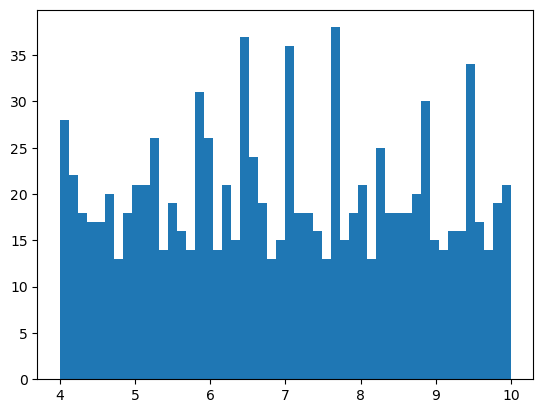

In [120]:
plt.hist(regression_dataset['Rating'], 50)
plt.show()

## Interpretation of the Distribution

As observed, the distribution of the ratings appears to be fairly uniform, with no significant skewness. This suggests that the values are evenly spread and do not show a strong bias toward higher or lower ratings.

## Gross Profit Distribution

The situation is different when analyzing the **gross profit**, as its distribution shows a different pattern compared to the rating. This indicates that the values may not be as evenly spread and could present variability or skewness that requires further investigation.

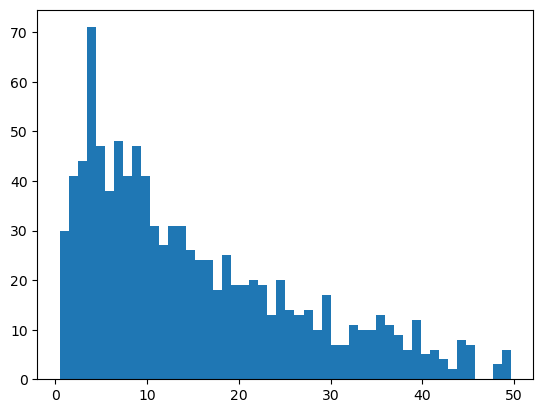

In [121]:
plt.hist(regression_dataset['gross income'], 50)
plt.show()

## Gross Profit Skewness

As we can observe, in this case the skewness is clearly present, with the majority of transactions showing a relatively low gross income.

The next step is to quantify this skewness by computing its exact value. This will give a more precise understanding of the distribution.

A small tip: using NumPy might not be the easiest way to compute it!

In [122]:
regression_dataset['gross income'].skew()

np.float64(0.8925698049581423)

## Encoding Categorical Variables

In this step, categorical variables are transformed into a numerical format so they can be used effectively in machine learning models. This process is essential, as most algorithms require numerical input to operate correctly.

## Categorical Encoding

Several variables (such as "Branch", "City", "Customer type", "Gender", "Product line", and "Payment") are categorical and cannot be directly processed by machine learning algorithms.

Encoding techniques are applied to transform these variables into numerical vectors, making them suitable for model training.

In [123]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

col_transform = make_column_transformer(
    (OneHotEncoder(), ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']),
    remainder='passthrough'
)

trasformed = col_transform.fit_transform(regression_dataset)

In [124]:
regression_dataset = pd.DataFrame(
    trasformed,
    columns= col_transform.get_feature_names_out()
)

regression_dataset.columns = regression_dataset.columns.str.replace('onehotencoder__', '')
regression_dataset.columns = regression_dataset.columns.str.replace('remainder__', '')


In [125]:
regression_dataset

,Branch_A,Branch_B,Branch_C,City_Mandalay,City_Naypyitaw,City_Yangon,Customer type_Member,Customer type_Normal,Gender_Female,Gender_Male,...,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel,Payment_Cash,Payment_Credit card,Payment_Ewallet,Unit price,Quantity,gross income,Rating
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,74.69,7.0,26.1415,9.1
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,15.28,5.0,3.8200,9.6
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,46.33,7.0,16.2155,7.4
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,58.22,8.0,23.2880,8.4
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,86.31,7.0,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,40.35,1.0,2.0175,6.2
996,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,97.38,10.0,48.6900,4.4
997,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,31.84,1.0,1.5920,7.7
998,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,65.82,1.0,3.2910,4.1


In [126]:
regression_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Branch_A                             1000 non-null   float64
 1   Branch_B                             1000 non-null   float64
 2   Branch_C                             1000 non-null   float64
 3   City_Mandalay                        1000 non-null   float64
 4   City_Naypyitaw                       1000 non-null   float64
 5   City_Yangon                          1000 non-null   float64
 6   Customer type_Member                 1000 non-null   float64
 7   Customer type_Normal                 1000 non-null   float64
 8   Gender_Female                        1000 non-null   float64
 9   Gender_Male                          1000 non-null   float64
 10  Product line_Electronic accessories  1000 non-null   float64
 11  Product line_Fashion accessorie

## Feature Scaling

Some features in the dataset, such as "Unit price" and "gross income", may benefit from standardization, especially considering the presence of skewness in certain variables.

Standardization is applied to scale these features, improving the performance and stability of the machine learning models.

In [127]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
regression_dataset['unit price_scl'] = scaler.fit_transform(regression_dataset[['Unit price']])
regression_dataset['gross income_scl'] = scaler.fit_transform(regression_dataset[['gross income']])
regression_dataset = regression_dataset.drop(columns=['Unit price','gross income'])


In [128]:
regression_dataset

,Branch_A,Branch_B,Branch_C,City_Mandalay,City_Naypyitaw,City_Yangon,Customer type_Member,Customer type_Normal,Gender_Female,Gender_Male,...,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel,Payment_Cash,Payment_Credit card,Payment_Ewallet,Quantity,Rating,unit price_scl,gross income_scl
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,7.0,9.1,0.718160,0.919607
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,5.0,9.6,-1.525303,-0.987730
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,7.0,7.4,-0.352781,0.071446
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,8.0,8.4,0.096214,0.675780
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,7.0,5.3,1.156959,1.267125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,6.2,-0.578600,-1.141750
996,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,10.0,4.4,1.574989,2.846340
997,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,7.7,-0.899958,-1.178109
998,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,4.1,0.383208,-1.032932


## Train-Test Split

The final step before training a machine learning model is splitting the dataset into training and test sets.

A common approach is to use a split ratio of 80:20 or 70:30, as these proportions generally provide a good balance between training and evaluation.

The resulting datasets are defined as follows:
- *X_train*: training features  
- *X_test*: test features  
- *y_train*: training labels  
- *y_test*: test labels

In [129]:
from sklearn.model_selection import train_test_split

X= regression_dataset.drop(columns=['Rating'])
y= regression_dataset['Rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

## Linear Regression

At this stage, a Linear Regression model is implemented to predict the **Rating**.

The model is defined as *regressor* and is trained using the previously prepared training dataset.

In [130]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

Once the model has been trained, its performance is evaluated using standard regression metrics.

The **Mean Squared Error (MSE)** and the **Mean Absolute Error (MAE)** are computed using sklearn and stored in the variables *MSE* and *MAE*, respectively.

Lower values of these metrics indicate better model performance, with values closer to zero reflecting higher predictive accuracy.

In [131]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_predict = regressor.predict(X_test)
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)


print('MSE =', MSE, '\nMAE =', MAE)

MSE = 3.110187291026073 
MAE = 1.5229214208487527


In [132]:
regression_dataset.corr()['Rating'].sort_values(ascending=False)

Rating                                 1.000000
City_Naypyitaw                         0.040740
Branch_C                               0.040740
Product line_Food and beverages        0.037546
Branch_A                               0.022714
City_Yangon                            0.022714
Customer type_Normal                   0.018889
Product line_Fashion accessories       0.015310
Payment_Credit card                    0.011935
Product line_Health and beauty         0.007540
Gender_Male                            0.004800
Payment_Cash                          -0.001114
Gender_Female                         -0.004800
unit price_scl                        -0.008778
Payment_Ewallet                       -0.010509
Product line_Electronic accessories   -0.012645
Product line_Sports and travel        -0.014658
Quantity                              -0.015815
Customer type_Member                  -0.018889
Product line_Home and lifestyle       -0.034351
gross income_scl                      -0

## Polynomial Regression

In this section, a Polynomial Regression model is implemented following a similar approach to Linear Regression, allowing for a more flexible and powerful representation of the relationship between variables.

The model is defined as *regressor*, while the polynomial feature transformer is defined as *poly_regressor*.

In [133]:
from sklearn.preprocessing import PolynomialFeatures
poly_regressor = PolynomialFeatures(degree=2)
X_train_poly = poly_regressor.fit_transform(X_train)
X_test_poly = poly_regressor.transform(X_test)

regressor = LinearRegression()
regressor.fit(X_train_poly, y_train)


LinearRegression()

## Performance Comparison

The model’s performance shows an improvement when using Polynomial Regression. Both MSE and MAE decrease, moving closer to zero, which indicates better predictive accuracy compared to Linear Regression.

In [134]:
y_predict_poly = regressor.predict(X_test_poly)
MSE = mean_squared_error(y_test, y_predict_poly)
MAE = mean_absolute_error(y_test, y_predict_poly)
print('MSE =', MSE, '\nMAE =', MAE)

MSE = 3.4526188576441217 
MAE = 1.569299653061178


## Logistic Regression

In this section, the dataset changes as the nature of the problem shifts from regression to classification.

The objective is to evaluate the quality of apples supplied to the supermarket chain, identifying which ones meet higher quality standards.

In [135]:
import pandas as pd

classification_dataset = pd.read_csv(r"C:\Users\Usuario\Downloads\apple_quality (1).csv", encoding='windows-1254')

In [136]:
classification_dataset.head(50)


,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
5,5.0,-3.425400,-1.409082,-1.913511,-0.555775,-3.853071,1.914616,-2.981523169,bad
6,6.0,1.331606,1.635956,0.875974,-1.677798,3.106344,-1.847417,2.414170509,good
7,7.0,-1.995462,-0.428958,1.530644,-0.742972,0.158834,0.974438,-1.470125066,good
8,8.0,-3.867632,-3.734514,0.986429,-1.207655,2.292873,4.080921,-4.871904758,bad
9,9.0,-0.727983,-0.442820,-4.092223,0.597513,0.393714,1.620857,2.185607723,bad


In [137]:
classification_dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


In [138]:
classification_dataset = classification_dataset.dropna()

## Data Preparation

The dataset is already clean, and most of the features are numerical. The only non-numerical variable is the target (label), which needs to be encoded before proceeding with model training.

In [139]:
classification_dataset['Quality']=classification_dataset['Quality'].map({
    'bad': 0,
    'good': 1
})



In [140]:
classification_dataset

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,1
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,1
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,0
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,1
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,1
...,...,...,...,...,...,...,...,...,...
3995,3995.0,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,0
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,1
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,0
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,1


## Train-Test Split

The dataset is then split again into training and test sets, using the same naming convention as before: *X_train*, *X_test*, *y_train*, and *y_test*.

In [141]:
from sklearn.model_selection import train_test_split
X= classification_dataset.drop(columns=['Quality','A_id'])
y= classification_dataset['Quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [142]:
from sklearn.linear_model import LogisticRegression
logistic_regressor = LogisticRegression()
logistic_regressor.fit(X_train, y_train)

LogisticRegression()

## Model Evaluation

A key metric for evaluating the performance of a classification model is the **F1 score**, which ideally should be higher than 0.80.

In addition, both **precision** and **recall** are considered, and their average should also be maximized, with target values ideally above 0.80.

In [143]:
from sklearn.metrics import classification_report

y_predict_test = logistic_regressor.predict(X_test)

print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75       401
           1       0.75      0.75      0.75       399

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800



In [144]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_name = X.columns
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [145]:
from sklearn.metrics import classification_report

y_predict_test = logistic_regressor.predict(X_test)

print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.88      0.42      0.57       401
           1       0.62      0.94      0.75       399

    accuracy                           0.68       800
   macro avg       0.75      0.68      0.66       800
weighted avg       0.75      0.68      0.66       800



c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Confusion Matrix

The confusion matrix is used to visualize the performance of the classification model, highlighting the categories where the model performs well and those where it makes errors.

This provides additional insights that can be used to further improve the model.

<Axes: >

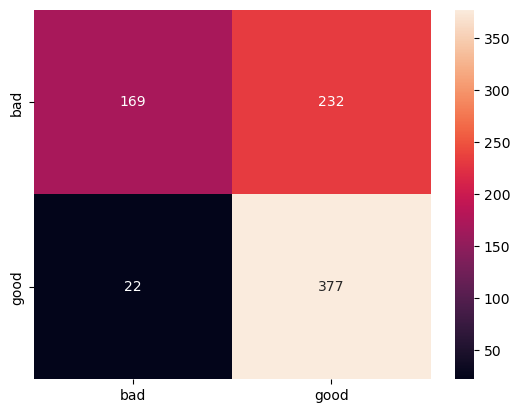

In [146]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot=True, fmt='d',xticklabels=['bad','good'], yticklabels=['bad','good'])

## Decision Tree

A Decision Tree model is implemented to evaluate whether it can improve performance compared to Logistic Regression.

Decision Trees are generally more powerful and flexible models, making them a useful alternative to explore for this classification task.

In [147]:
from sklearn.tree import DecisionTreeClassifier

dt= DecisionTreeClassifier(criterion='gini')
dt.fit(X_train, y_train)
y_predict_d = dt.predict(X_test)


<Axes: >

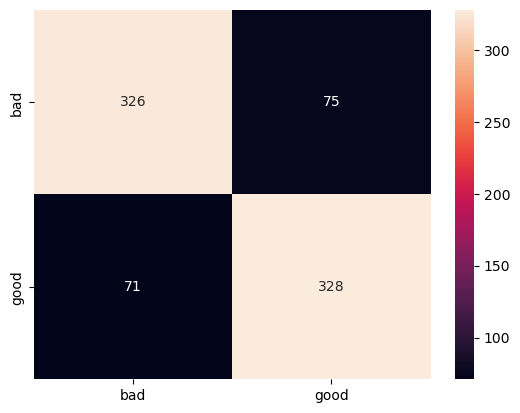

In [148]:
cm = confusion_matrix(y_test, y_predict_d)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['bad','good'], yticklabels=['bad','good'])

## Model Comparison

The number of errors is lower compared to those made by the Logistic Regression model.

This indicates that the Decision Tree achieves better performance and higher accuracy on this classification task.

## Feature Importance

Feature importance is analyzed to identify which variables contribute the most to the Decision Tree model.

This helps to understand which features have the greatest impact on the model’s predictions.

In [149]:
importances = dt.feature_importances_

feature_importance = pd.DataFrame(
    {'feature' : feature_name,
     'importance' : importances
    })

print(feature_importance.sort_values(by='importance', ascending=False))

       feature  importance
5     Ripeness    0.205631
0         Size    0.171086
2    Sweetness    0.157567
6      Acidity    0.140260
4    Juiciness    0.121942
1       Weight    0.103401
3  Crunchiness    0.100113


## K-Means Clustering

K-Means Clustering is introduced as one of the most widely used unsupervised learning algorithms.

## Data Preparation

The target variable (label) is removed before applying K-Means Clustering, as this is an unsupervised algorithm and does not require labeled data.

In [150]:
clustering_dataset = classification_dataset.drop(columns=['Quality','A_id'])


In [151]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=2)
kmean.fit(clustering_dataset)
clustering_dataset['kmean'] = kmean.labels_
clustering_dataset



,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,kmean
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,1
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,1
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,1
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,1
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,1
...,...,...,...,...,...,...,...,...
3995,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,0
3996,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,1
3997,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,0
3998,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,1


## Prediction

A prediction is performed using the trained model to determine the quality category corresponding to the input apple.

In [152]:
first_ten_apple = clustering_dataset.drop(columns=['kmean']).iloc[0:10]
first_ten_apple
cluster = kmean.predict(first_ten_apple)

In [153]:
cluster

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0], dtype=int32)

## Cluster Analysis

With the number of clusters set to 2, the model assigns each apple to one of two categories: good or bad.

When increasing the number of clusters to 3, an additional intermediate category emerges. In this case, the cluster labeled as 1 represents apples of medium quality, revealing a more nuanced segmentation of the data.

In [154]:
from sklearn.cluster import KMeans
clustering_dataset = clustering_dataset.drop(columns=['kmean'])
kmean_3 = KMeans(n_clusters=3)
kmean_3.fit(clustering_dataset)
clustering_dataset['kmean_3'] = kmean_3.labels_
clustering_dataset

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,kmean_3
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,2
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,2
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,0
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,0
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,0
...,...,...,...,...,...,...,...,...
3995,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,1
3996,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,0
3997,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,1
3998,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,2


In [155]:
first_ten_apple_3 = clustering_dataset.drop(columns=['kmean_3']).iloc[0:10]

cluster_3 = kmean_3.predict(first_ten_apple_3)
cluster_3

array([2, 2, 0, 0, 0, 1, 0, 2, 2, 1], dtype=int32)

## Time Series

The final part of the project focuses on time series analysis. The dataset previously used for regression is actually a time series, where the time component was removed as it was not relevant for that specific task.

In this section, the goal is to analyze how **gross income evolves over time**. Starting from the original dataset (*regression_raw_dataset*), only the "Date" and "gross income" columns are retained, creating a new dataset named *timeseries_dataset*.

In [156]:
timeseries_dataset = regression_raw_dataset[['Time','gross income']]

In [157]:
timeseries_dataset.head(100)

,Time,gross income
0,13:08,26.1415
1,10:29,3.8200
2,13:23,16.2155
3,20:33,23.2880
4,10:37,30.2085
...,...,...
95,20:38,4.8580
96,10:25,43.9350
97,13:11,3.7350
98,10:16,7.9125


## Time Series Modeling

A Linear Regression model is applied to the time series data, following the same approach used previously, in order to model and analyze the trend of gross income over time.

In [158]:
import pandas as pd

timeseries_dataset['Time'] = pd.to_datetime(timeseries_dataset['Time'], format='%H:%M')
timeseries_dataset['Time'] = timeseries_dataset['Time'].dt.hour * 60 + timeseries_dataset['Time'].dt.minute

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7748\2129027196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timeseries_dataset['Time'] = pd.to_datetime(timeseries_dataset['Time'], format='%H:%M')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7748\2129027196.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timeseries_dataset['Time'] = timeseries_dataset['Time'].dt.hour * 60 + timeseries_dataset['Time'].dt.minute


In [159]:
from sklearn.linear_model import LinearRegression
X= timeseries_dataset[['Time']]
y= timeseries_dataset['gross income']
regressor= LinearRegression()
regressor.fit(X,y)

LinearRegression()

In [160]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

regressor = LinearRegression()
regressor.fit(X_train,y_train)



LinearRegression()

## Model Evaluation

The model is evaluated using the standard regression metrics: **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)**, to assess its performance on the time series data.

In [161]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_predict = regressor.predict(X_test)

MAE = mean_absolute_error(y_test, y_predict)
MSE = mean_squared_error(y_test, y_predict)

print('MSE =', MSE, '\nMAE =', MAE)

MSE = 148.47211769334837 
MAE = 9.998676789237726


## Time Series with XGBoost (Optional)

As a more advanced approach for time series modeling, XGBoost can be applied to potentially achieve better performance compared to Linear Regression. This step is optional and not required to complete the project.

An XGBoost model is implemented to predict the evolution of gross income over time, following a similar pipeline: data preparation, train-test split, model training, and evaluation using metrics such as MSE and MAE. This allows for a comparison of performance between Linear Regression and a more powerful, non-linear model.

In [162]:
# Time Series with XGBoost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# Prepare dataset
timeseries_dataset["Date"] = pd.to_datetime(timeseries_dataset["Date"])
timeseries_dataset = timeseries_dataset.sort_values("Date")

# Convert date to numerical feature (timestamp)
timeseries_dataset["Date_numeric"] = timeseries_dataset["Date"].map(pd.Timestamp.toordinal)

# Features and target
X = timeseries_dataset[["Date_numeric"]]
y = timeseries_dataset["gross income"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
regressor = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)

# Training
regressor.fit(X_train, y_train)

# Prediction
y_pred = regressor.predict(X_test)

# Evaluation
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

print("MSE:", MSE)
print("MAE:", MAE)

ModuleNotFoundError: No module named 'xgboost'